# Notebook 06 — Evaluation

**Pipeline:** Adaptive Classical Vision Pipeline for Cut-Edge Detection  
**Step 6:** Compare pipeline outputs against ground truth COCO annotations

**Input:**
- Ground truth annotations: `data/labels/_annotations_coco.json`
- Metric measurements: `outputs/05_metric/measurements.json`
- Detected lines: `outputs/04_hough/lines.json`
- Calibration data: `outputs/02_rectified/calibration.json`
- Rectified images: `outputs/02_rectified/`

**Output:**
- Evaluation report saved to `outputs/06_evaluation/report.json`
- Summary table saved to `outputs/06_evaluation/summary.png`

**Metrics computed:**
- **IoU** — overlap between predicted edge mask and ground truth mask
- **Precision / Recall / F1** — detection quality
- **RMSE / MAE** — metric accuracy of distance measurements
- **Distance Error** — absolute error between predicted and GT edge x position in mm
- **Processing speed** — seconds per image

## 1. Imports and configuration

In [14]:
!pip install opencv-python numpy matplotlib pycocotools

In [15]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import json
import time
from pathlib import Path
from pycocotools import mask as coco_mask

In [16]:
# ── Paths ──────────────────────────────────────────────────────────────────
ANNOTATIONS_PATH = Path("data/labels/_annotations_coco.json")
CALIB_PATH       = Path("outputs/02_rectified/calibration.json")
LINES_PATH       = Path("outputs/04_hough/lines.json")
METRIC_PATH      = Path("outputs/05_metric/measurements.json")
RECTIFIED_DIR    = Path("outputs/02_rectified")
OUTPUT_DIR       = Path("outputs/06_evaluation")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ── Evaluation parameters ──────────────────────────────────────────────────
# Width in pixels to draw predicted edge lines when computing mask IoU
EDGE_LINE_WIDTH  = 10   # px — tolerance band around detected line

# IoU threshold to consider a detection as a true positive
IOU_THRESHOLD    = 0.1  # low because edges are thin structures

# Load all data
with open(ANNOTATIONS_PATH) as f:
    coco_data = json.load(f)
with open(CALIB_PATH) as f:
    calibration_data = json.load(f)
with open(LINES_PATH) as f:
    hough_results = json.load(f)
with open(METRIC_PATH) as f:
    metric_results = json.load(f)

print(f"GT images        : {len(coco_data['images'])}")
print(f"GT annotations   : {len(coco_data['annotations'])}")
print(f"Calibrated images: {len(calibration_data)}")
print(f"Images with lines: {len(hough_results)}")
print(f"Images with metric:{len(metric_results)}")

GT images        : 22
GT annotations   : 98
Calibrated images: 22
Images with lines: 22
Images with metric:9


## 2. Ground truth parsing

Parse the COCO annotations to extract cut_edge segmentation masks per image.
Category id 1 = cut_edge, category id 2 = qr_code.

In [17]:
# Build lookup: image_name → image info
img_info = {img['file_name']: img for img in coco_data['images']}
img_id_to_name = {img['id']: img['file_name'] for img in coco_data['images']}

# Category ids
cat_name_to_id = {c['name']: c['id'] for c in coco_data['categories']}
CUT_EDGE_CAT   = cat_name_to_id.get('cut_edge', 1)
print(f"Categories: {cat_name_to_id}")
print(f"Cut edge category id: {CUT_EDGE_CAT}")

# Group annotations by image
gt_by_image = {}
for ann in coco_data['annotations']:
    if ann['category_id'] != CUT_EDGE_CAT:
        continue
    name = img_id_to_name[ann['image_id']]
    gt_by_image.setdefault(name, []).append(ann)

print(f"Images with cut_edge GT: {len(gt_by_image)}")

Categories: {'Michelin-Proyect-Challenge-Seg': 0, 'cut_edge': 1, 'qr_code': 2}
Cut edge category id: 1
Images with cut_edge GT: 17


## 3. Mask generation

Convert both GT annotations and predicted lines to binary masks for IoU computation.

In [18]:
def gt_annotation_to_mask(ann: dict, img_h: int, img_w: int) -> np.ndarray:
    """
    Convert a COCO annotation to a binary mask.
    Handles Roboflow compressed RLE format.
    """
    seg = ann['segmentation']

    if isinstance(seg, dict):
        # Roboflow compressed RLE: counts is a string, need to encode to bytes
        rle = {
            'size'  : seg['size'],
            'counts': seg['counts'].encode('utf-8') if isinstance(seg['counts'], str) else seg['counts']
        }
        m = coco_mask.decode(rle)
    else:
        # Polygon format
        rle = coco_mask.frPyObjects(seg, img_h, img_w)
        m   = coco_mask.decode(rle)
        if m.ndim == 3:
            m = m[:, :, 0]

    return (m > 0).astype(np.uint8)

## 4. Detection evaluation (IoU, Precision, Recall, F1)

For each image, match predicted edges to GT edges using IoU.
A prediction is a True Positive if its best IoU with any GT mask ≥ IOU_THRESHOLD.

In [19]:
def evaluate_detection(image_name: str) -> dict | None:
    """
    Evaluate detection quality for one image.

    Returns dict with TP, FP, FN, precision, recall, F1, mean_iou.
    """
    if image_name not in gt_by_image:
        return None
    if image_name not in hough_results:
        return None

    info   = img_info[image_name]
    img_h  = info['height']
    img_w  = info['width']

    gt_anns  = gt_by_image[image_name]
    pred_edges = hough_results[image_name]['cut_edges_px']

    # Build GT masks
    gt_masks = [gt_annotation_to_mask(ann, img_h, img_w) for ann in gt_anns]

    # Build predicted masks
    pred_masks = [
        predicted_line_to_mask(e[0], e[1], e[2], e[3], img_h, img_w)
        for e in pred_edges
    ]

    # Match predictions to GT greedily by IoU
    matched_gt  = set()
    TP          = 0
    iou_scores  = []

    for pred_mask in pred_masks:
        best_iou = 0.0
        best_gt  = -1
        for j, gt_mask in enumerate(gt_masks):
            if j in matched_gt:
                continue
            iou = compute_iou(pred_mask, gt_mask)
            if iou > best_iou:
                best_iou = iou
                best_gt  = j

        if best_iou >= IOU_THRESHOLD and best_gt >= 0:
            TP += 1
            matched_gt.add(best_gt)
            iou_scores.append(best_iou)

    FP        = len(pred_masks) - TP
    FN        = len(gt_masks)   - TP
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0.0
    recall    = TP / (TP + FN) if (TP + FN) > 0 else 0.0
    f1        = (2 * precision * recall / (precision + recall)
                 if (precision + recall) > 0 else 0.0)

    return {
        'TP'       : TP,
        'FP'       : FP,
        'FN'       : FN,
        'precision': round(precision, 4),
        'recall'   : round(recall,    4),
        'f1'       : round(f1,        4),
        'mean_iou' : round(float(np.mean(iou_scores)) if iou_scores else 0.0, 4),
        'n_gt'     : len(gt_masks),
        'n_pred'   : len(pred_masks)
    }

## 5. Metric evaluation (RMSE, MAE, Distance Error)

Compare the predicted distance measurements against GT bounding box positions.

In [20]:
def evaluate_metric(image_name: str) -> dict | None:
    """
    Evaluate metric accuracy for one image.

    Uses GT bbox x positions (converted to mm) as reference for
    the predicted edge x positions.
    """
    if image_name not in gt_by_image:
        return None
    if image_name not in metric_results:
        return None

    calib    = calibration_data[image_name]
    scale    = float(calib['px_per_mm'])
    tl_x     = float(calib['corners_px'][0][0])

    # GT edge x positions in mm (centre of bbox)
    gt_anns  = gt_by_image[image_name]
    gt_x_mm = sorted([
    (float(ann['bbox'][0]) + float(ann['bbox'][2]) / 2 - tl_x) / scale
    for ann in gt_anns
    ])

    # Predicted edge x positions in mm
    pred_measurements = metric_results[image_name]['measurements']
    pred_x_mm = sorted([m['edge_x_mm'] for m in pred_measurements])

    # Match by order (both sorted left to right)
    n_match = min(len(gt_x_mm), len(pred_x_mm))
    if n_match == 0:
        return None

    errors = [abs(pred_x_mm[i] - gt_x_mm[i]) for i in range(n_match)]
    rmse   = float(np.sqrt(np.mean([e**2 for e in errors])))
    mae    = float(np.mean(errors))

    return {
        'gt_x_mm'  : [round(x, 2) for x in gt_x_mm],
        'pred_x_mm': [round(x, 2) for x in pred_x_mm],
        'errors_mm': [round(e, 2) for e in errors],
        'mae_mm'   : round(mae,  2),
        'rmse_mm'  : round(rmse, 2),
        'n_matched': n_match
    }

## 6. Speed evaluation

In [21]:
def measure_speed(image_name: str, n_runs: int = 5) -> float:
    """
    Measure average processing time per image by re-running the full pipeline.
    Returns mean time in seconds.
    """
    import sys
    sys.path.insert(0, str(Path(".").resolve()))

    img_path = RECTIFIED_DIR / image_name

    times = []
    for _ in range(n_runs):
        t0  = time.perf_counter()
        img = cv2.imread(str(img_path))

        # Step 3: segmentation + Canny
        gray    = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        blurred = cv2.GaussianBlur(gray, (5, 5), 0)
        _, mask = cv2.threshold(blurred, 0, 255,
                                cv2.THRESH_BINARY + cv2.THRESH_OTSU)
        kernel  = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))
        mask    = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
        edges   = cv2.Canny(mask, 50, 150)

        # Step 4: Hough
        segs = cv2.HoughLinesP(edges, 1, np.pi/180,
                               threshold=50, minLineLength=80, maxLineGap=30)

        times.append(time.perf_counter() - t0)

    return float(np.mean(times))

## 7. Run full evaluation

In [22]:
eval_results = {}

for image_name in calibration_data:
    det   = evaluate_detection(image_name)
    met   = evaluate_metric(image_name)
    speed = measure_speed(image_name)

    if det is None:
        continue

    eval_results[image_name] = {
        'detection': det,
        'metric'   : met,
        'speed_s'  : round(speed, 4)
    }

    print(f"  {image_name:30s}  "
          f"P={det['precision']:.2f}  R={det['recall']:.2f}  "
          f"F1={det['f1']:.2f}  IoU={det['mean_iou']:.2f}  "
          f"MAE={met['mae_mm'] if met else 'N/A':>7}mm  "
          f"t={speed:.3f}s")

# Save report
with open(OUTPUT_DIR / "report.json", "w") as f:
    json.dump(eval_results, f, indent=2)
print(f"\nSaved to {OUTPUT_DIR / 'report.json'}")

  Multimedia_31.jpg               P=0.02  R=0.50  F1=0.05  IoU=0.30  MAE= 144.57mm  t=0.023s
  Multimedia_32.jpg               P=0.00  R=0.00  F1=0.00  IoU=0.00  MAE=  89.37mm  t=0.022s
  Multimedia_33.jpg               P=0.03  R=0.50  F1=0.06  IoU=0.16  MAE= 135.66mm  t=0.021s
  Multimedia_34.jpg               P=0.04  R=0.50  F1=0.07  IoU=0.36  MAE=   9.44mm  t=0.021s
  Multimedia_35.jpg               P=0.00  R=0.00  F1=0.00  IoU=0.00  MAE=    N/Amm  t=0.013s
  Multimedia_36.jpg               P=0.00  R=0.00  F1=0.00  IoU=0.00  MAE=    N/Amm  t=0.014s
  Multimedia_37.jpg               P=0.00  R=0.00  F1=0.00  IoU=0.00  MAE=    N/Amm  t=0.017s
  Multimedia_38.jpg               P=0.00  R=0.00  F1=0.00  IoU=0.00  MAE=    N/Amm  t=0.016s
  Multimedia_39.jpg               P=0.04  R=0.50  F1=0.07  IoU=0.12  MAE=  11.63mm  t=0.020s
  Multimedia_40.jpg               P=0.00  R=0.00  F1=0.00  IoU=0.00  MAE= 225.12mm  t=0.017s
  Multimedia_41.jpg               P=0.08  R=1.00  F1=0.15  IoU=0.16  M

## 8. Aggregate metrics

In [23]:
precisions = [r['detection']['precision'] for r in eval_results.values()]
recalls    = [r['detection']['recall']    for r in eval_results.values()]
f1s        = [r['detection']['f1']        for r in eval_results.values()]
ious       = [r['detection']['mean_iou']  for r in eval_results.values()]
maes       = [r['metric']['mae_mm']  for r in eval_results.values() if r['metric']]
rmses      = [r['metric']['rmse_mm'] for r in eval_results.values() if r['metric']]
speeds     = [r['speed_s'] for r in eval_results.values()]

print("=" * 55)
print("AGGREGATE EVALUATION RESULTS")
print("=" * 55)
print(f"Images evaluated : {len(eval_results)}")
print(f"")
print(f"Detection metrics:")
print(f"  Mean Precision : {np.mean(precisions):.4f}")
print(f"  Mean Recall    : {np.mean(recalls):.4f}")
print(f"  Mean F1        : {np.mean(f1s):.4f}")
print(f"  Mean IoU       : {np.mean(ious):.4f}")
print(f"")
print(f"Metric accuracy:")
print(f"  Mean MAE  (mm) : {np.mean(maes):.2f}")
print(f"  Mean RMSE (mm) : {np.mean(rmses):.2f}")
print(f"")
print(f"Speed:")
print(f"  Mean time/img  : {np.mean(speeds):.4f} s")
print(f"  Imgs per second: {1/np.mean(speeds):.2f}")
print(f"  Imgs per minute: {60/np.mean(speeds):.1f}")
print("=" * 55)

AGGREGATE EVALUATION RESULTS
Images evaluated : 17

Detection metrics:
  Mean Precision : 0.0148
  Mean Recall    : 0.2059
  Mean F1        : 0.0276
  Mean IoU       : 0.0728

Metric accuracy:
  Mean MAE  (mm) : 103.75
  Mean RMSE (mm) : 104.14

Speed:
  Mean time/img  : 0.0191 s
  Imgs per second: 52.36
  Imgs per minute: 3141.4


## 9. Summary table plot

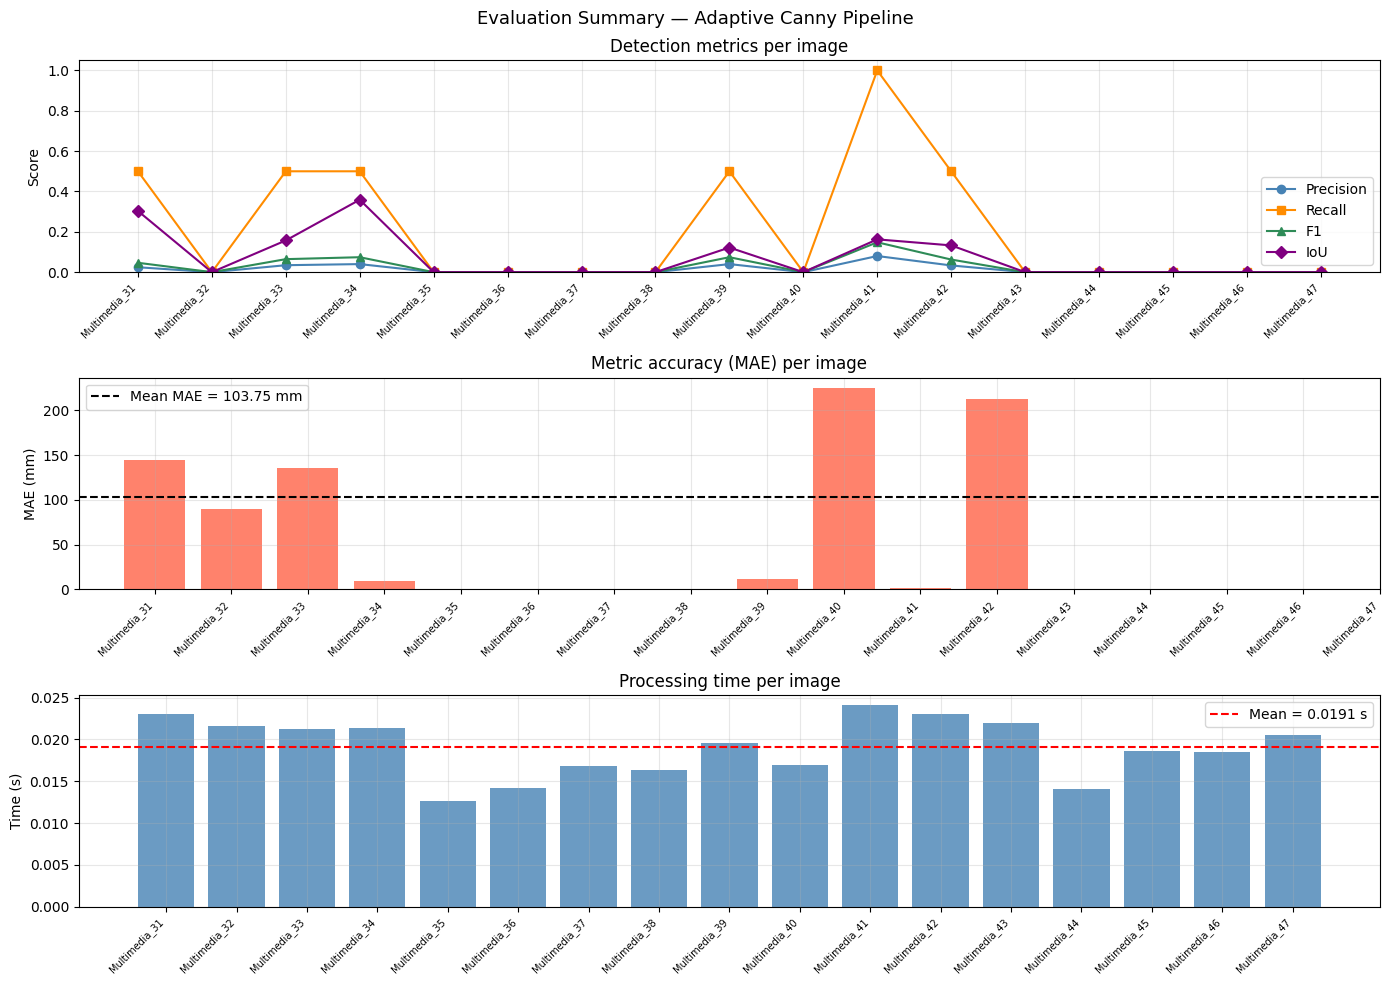

In [24]:
names = list(eval_results.keys())
x     = range(len(names))
xlabels = [n.replace('.jpg', '') for n in names]

fig, axes = plt.subplots(3, 1, figsize=(14, 10))
fig.suptitle('Evaluation Summary — Adaptive Canny Pipeline', fontsize=13)

# Precision / Recall / F1
axes[0].plot(x, precisions, 'o-', color='steelblue',  label='Precision')
axes[0].plot(x, recalls,    's-', color='darkorange',  label='Recall')
axes[0].plot(x, f1s,        '^-', color='seagreen',    label='F1')
axes[0].plot(x, ious,       'D-', color='purple',      label='IoU')
axes[0].set_ylim(0, 1.05)
axes[0].set_xticks(x); axes[0].set_xticklabels(xlabels, rotation=45, ha='right', fontsize=7)
axes[0].set_ylabel('Score'); axes[0].set_title('Detection metrics per image')
axes[0].legend(loc='lower right'); axes[0].grid(alpha=0.3)

# MAE
mae_vals = [eval_results[n]['metric']['mae_mm']
            if eval_results[n]['metric'] else np.nan for n in names]
axes[1].bar(x, mae_vals, color='tomato', alpha=0.8)
axes[1].axhline(np.nanmean(mae_vals), color='black', linestyle='--',
                label=f'Mean MAE = {np.nanmean(mae_vals):.2f} mm')
axes[1].set_xticks(x); axes[1].set_xticklabels(xlabels, rotation=45, ha='right', fontsize=7)
axes[1].set_ylabel('MAE (mm)'); axes[1].set_title('Metric accuracy (MAE) per image')
axes[1].legend(); axes[1].grid(alpha=0.3)

# Speed
axes[2].bar(x, speeds, color='steelblue', alpha=0.8)
axes[2].axhline(np.mean(speeds), color='red', linestyle='--',
                label=f'Mean = {np.mean(speeds):.4f} s')
axes[2].set_xticks(x); axes[2].set_xticklabels(xlabels, rotation=45, ha='right', fontsize=7)
axes[2].set_ylabel('Time (s)'); axes[2].set_title('Processing time per image')
axes[2].legend(); axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'summary.png', dpi=150)
plt.show()

## 10. Summary

| Metric | Description |
|--------|-------------|
| Precision | TP / (TP + FP) — how many detections are correct |
| Recall | TP / (TP + FN) — how many GT edges are found |
| F1 | Harmonic mean of Precision and Recall |
| IoU | Mask overlap between predicted and GT edge regions |
| MAE (mm) | Mean absolute error of edge x position in mm |
| RMSE (mm) | Root mean square error of edge x position in mm |
| Speed | Processing time per image (s) and throughput (img/s, img/min) |

**Output folder:** `outputs/06_evaluation/`  
**Report file:** `outputs/06_evaluation/report.json`